In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RAW = '../../data/raw'
OUT = '../../data/processed/combined_hourly.csv'
os.makedirs(os.path.dirname(OUT), exist_ok=True)

CONTINUOUS = ['load_mw', 'temperature_c', 'precipitation_mm',
              'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu']

### 1. Load & align datetimes

CAISO and economic files are tz-aware (`-08:00`); weather is tz-naive. We convert everything to Pacific time then strip the tz so all three join cleanly on a naive index.

In [20]:
def load(path, dt_col='datetime'):
    df = pd.read_csv(path)   # read raw — no parse_dates
    raw = df[dt_col].astype(str)
    # Detect tz-aware strings (e.g. "2019-01-01 00:00:00-08:00")
    if raw.str.contains(r'[+-]\d{2}:\d{2}$', regex=True).any():
        dt = pd.to_datetime(raw, utc=True).dt.tz_convert('America/Los_Angeles').dt.tz_localize(None)
    else:
        dt = pd.to_datetime(raw)
    df[dt_col] = dt
    return df.set_index(dt_col).sort_index()

caiso   = load(f'{RAW}/caiso_hourly.csv')
weather = load(f'{RAW}/weather_hourly.csv')
econ    = load(f'{RAW}/economic_hourly.csv')

for name, d in [('caiso', caiso), ('weather', weather), ('econ', econ)]:
    print(f'{name:<8} {d.shape}  {d.index[0]}  →  {d.index[-1]}')

caiso    (52607, 1)  2019-01-01 00:00:00  →  2024-12-31 23:00:00
weather  (52608, 5)  2019-01-01 00:00:00  →  2024-12-31 23:00:00
econ     (52608, 6)  2019-01-01 00:00:00  →  2024-12-31 23:00:00


### 2. Merge

In [21]:
df = caiso.join(weather, how='inner').join(econ, how='inner')
print(f'Combined: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Range:    {df.index[0]}  →  {df.index[-1]}')
df.head(3)

Combined: 52,619 rows × 12 columns
Range:    2019-01-01 00:00:00  →  2024-12-31 23:00:00


,load_mw,temperature_c,precipitation_mm,solar_radiation_wm2,windspeed_ms,humidity_pct,gas_price_mmbtu,is_holiday,is_weekend,hour_of_day,day_of_week,month
datetime,,,,,,,,,,,,
2019-01-01 00:00:00,21934,4.525,0.0,0.0,3.6525,57.50,NaN,0,0,0,1,1
2019-01-01 01:00:00,21188,4.475,0.0,0.0,3.1250,56.50,NaN,0,0,1,1,1
2019-01-01 02:00:00,20613,3.475,0.0,0.0,3.1950,57.25,NaN,0,0,2,1,1


### 3. Missing values

In [22]:
missing = df.isnull().mean() * 100
print('Missing % per column:')
print(missing.round(2).to_string())

Missing % per column:
load_mw                0.00
temperature_c          0.00
precipitation_mm       0.00
solar_radiation_wm2    0.00
windspeed_ms           0.00
humidity_pct           0.00
gas_price_mmbtu        4.06
is_holiday             0.00
is_weekend             0.00
hour_of_day            0.00
day_of_week            0.00
month                  0.00


In [23]:
df[CONTINUOUS] = df[CONTINUOUS].interpolate(method='time', limit=6)
df[CONTINUOUS] = df[CONTINUOUS].ffill()

for col in CONTINUOUS:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

remaining = df.isnull().sum()
print('NaN remaining after fill:')
print(remaining[remaining > 0].to_string() if remaining.any() else '  None — dataset is complete')

NaN remaining after fill:
  None — dataset is complete


In [24]:
df.describe().round(2)

,load_mw,temperature_c,precipitation_mm,solar_radiation_wm2,windspeed_ms,humidity_pct,gas_price_mmbtu,is_holiday,is_weekend,hour_of_day,day_of_week,month
count,52619.00,52619.00,52619.00,52619.00,52619.00,52619.00,52619.00,52619.0,52619.00,52619.00,52619.0,52619.00
mean,25236.66,17.36,0.06,218.48,2.49,60.11,3.27,0.0,0.29,11.50,3.0,6.52
std,4761.74,7.70,0.26,296.98,1.09,20.41,1.87,0.0,0.45,6.92,2.0,3.45
min,14853.00,-0.95,0.00,0.00,0.25,6.75,1.21,0.0,0.00,0.00,0.0,1.00
25%,21917.50,11.40,0.00,0.00,1.70,43.75,2.16,0.0,0.00,5.00,1.0,4.00
50%,24280.00,16.52,0.00,12.50,2.25,62.50,2.61,0.0,0.00,11.00,3.0,7.00
75%,27098.00,22.30,0.00,415.62,3.12,77.00,3.67,0.0,1.00,17.00,5.0,10.00
max,51292.00,44.68,4.72,1017.25,10.42,99.75,23.86,0.0,1.00,23.00,6.0,12.00


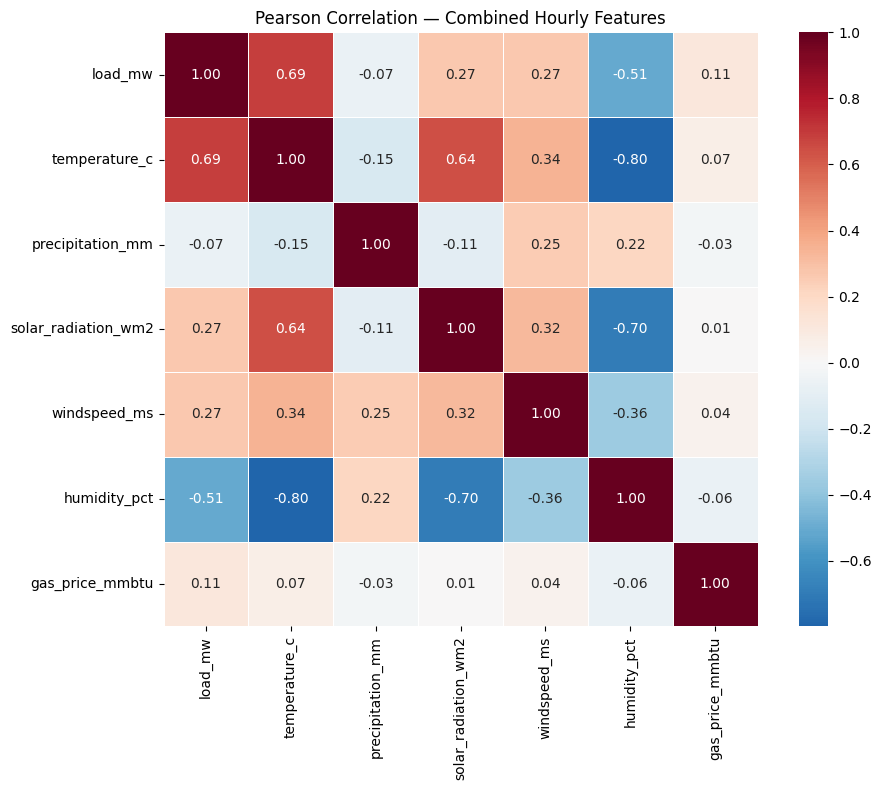

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[CONTINUOUS].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.4, ax=ax
)
ax.set_title('Pearson Correlation — Combined Hourly Features')
plt.tight_layout()
plt.savefig('../../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

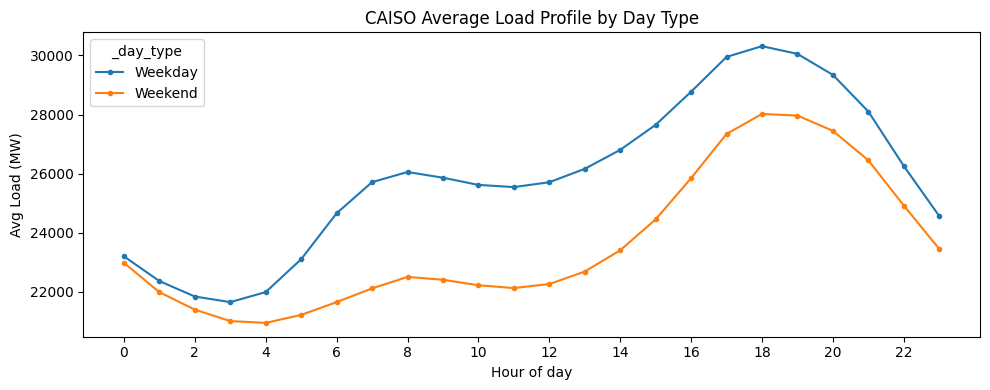

In [ ]:
df['_day_type'] = 'Weekday'
df.loc[df['is_weekend'] == 1, '_day_type'] = 'Weekend'
df.loc[df['is_holiday'] == 1, '_day_type'] = 'Holiday'

profile = df.groupby(['hour_of_day', '_day_type'])['load_mw'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 4))
profile.plot(ax=ax, marker='o', markersize=3)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg Load (MW)')
ax.set_title('CAISO Average Load Profile by Day Type')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig('../../data/processed/load_profiles.png', dpi=150)
plt.show()

df = df.drop(columns='_day_type')

### 4. Save

In [27]:
df.to_csv(OUT)
print(f'Saved {len(df):,} rows × {len(df.columns)} columns → {OUT}')
print('Columns:', df.columns.tolist())

Saved 52,619 rows × 12 columns → ../../data/processed/combined_hourly.csv
Columns: ['load_mw', 'temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu', 'is_holiday', 'is_weekend', 'hour_of_day', 'day_of_week', 'month']
